In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os, h5py, time, psutil

import numpy as np
import healpy as hp
import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
import matplotlib.pyplot as plt

from tqdm import tqdm, trange
from sklearn.neighbors import BallTree

# from deepsphere.utils import split_sparse_dense_matmul
# from deep_lss.utils import layers
from deepsphere import healpy_layers

from msfm.grid_pipeline import GridPipeline
from msfm.utils import scales, files

24-05-27 03:27:45   imports.py INF   Setting up healpy to run on 32 CPUs 
24-05-27 03:27:50   imports.py INF   Setting up healpy to run on 32 CPUs 


# example map

In [3]:
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v8/linear_bias/tfrecords/grid/DESy3_grid_dmb_0000.tfrecord"
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias_no_smoothing.yaml"
conf = files.load_config(conf)
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

grid_pipe = GridPipeline(
    conf=conf,
    params=params,
    with_lensing=True,
    with_clustering=True,
    with_padding=True,
    apply_norm=False
)

dv_pix = grid_pipe.data_vec_pix
n_dv_pix = len(dv_pix)

n_side = 512
n_pix = hp.nside2npix(n_side)
n_noise = 3

n_channels = grid_pipe.n_z_metacal + grid_pipe.n_z_maglim
n_z_metacal = grid_pipe.n_z_metacal

mask_dict = files.get_tomo_dv_masks(conf)
mask = tf.concat([mask_dict["metacal"], mask_dict["maglim"]], axis=1)

batch_size = 52

dset = grid_pipe.get_dset(
        tfr_pattern=tfr_pattern,
        local_batch_size=batch_size,
        n_readers=1,
        n_prefetch=0,
)

for dv, cosmo, index in dset.take(1):
    pass

print(dv.shape)

24-05-27 03:27:50     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
24-05-27 03:27:50     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
24-05-27 03:27:52     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
24-05-27 03:27:53 grid_pipelin INF   n_workers is not set, using tf.data.AUTOTUNE. This might produce unexpected RAM usage. 
24-05-27 03:27:53 grid_pipelin INF   drop_remainder is not set, using drop_remainder = False 
24-05-27 03:27:53 grid_pipelin INF   Including noise_indices = [0] 
24-05-27 03:27:53 grid_pipelin INF   Interleaving with n_readers = 1 
24-05-27 03:27:53 grid_pipelin INF   Batching into 52 elements locally 
24-05-27 03:27:54 grid_pipelin WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set t

In [4]:
n_sigma_support = 3
# n_sigma_support = 4
# n_sigma_support = 5
# n_sigma_support = 7
# n_sigma_support = 9

# smoothing_layer = layers.HealpySmoothingLayer(
smoothing_layer = healpy_layers.HealpySmoothing(
    nside=n_side, 
    indices=dv_pix,
    # mask=mask,
    fwhm=[22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5],
    # fwhm=20,
    # sigma=[9.78, 6.91, 5.65, 3.99, 27.66, 19.14, 14.94, 12.62],
    # fwhm=10,
    # sigma=10,
    # per_channel_repetitions=[6, 3, 2, 1, 48, 23, 14, 10],
    n_sigma_support=n_sigma_support,
    # data_path="/pscratch/sd/a/athomsen/debug/smoothing_kernel",
)

smoothing_layer = tf.function(smoothing_layer)

actual_fwhm = smoothing_layer.fwhm_arcmin * np.sqrt(smoothing_layer.per_channel_repetitions)
# actual_fwhm = [20] * n_channels

Using the per channel smoothing repetitions [ 6  3  2  1 48 23 14 10]
Using the per channel smoothing scales sigma = [ 9.78  6.91  5.65  3.99 27.66 19.14 14.94 12.62] arcmin, fwhm = [23.03 16.28 13.29  9.4  65.13 45.08 35.17 29.73] arcmin
Creating tree for 464896 pixels and radius n_sigma_support * sigma = 11.98 arcmin
The maximal number of neighbors within that radius is 13


querying the tree: 100%|██████████| 100/100 [00:17<00:00,  5.63it/s]


Successfully created the sparse kernel tensor


In [5]:
# trace the function once
tf_smooth = smoothing_layer(dv)

Successfully built the smoothing layer


In [6]:
%%time
tf_smooth = smoothing_layer(dv)

CPU times: user 43.4 ms, sys: 3.74 ms, total: 47.1 ms
Wall time: 69.9 ms


In [7]:
# 3 sigma: 133 ms, 13 neighbors
# 4 sigma: 243 ms, 21 neighbors
# 5 sigma: 501 ms, 31 neighbors


# plotting

In [7]:
i_batch = 0
i_channel = 4

In [8]:
raw_maps = np.zeros((n_pix, n_channels))
raw_maps[dv_pix] = dv[i_batch]

### healpy

[None, (50.0, 800.0), (1e-08, 0.001)]

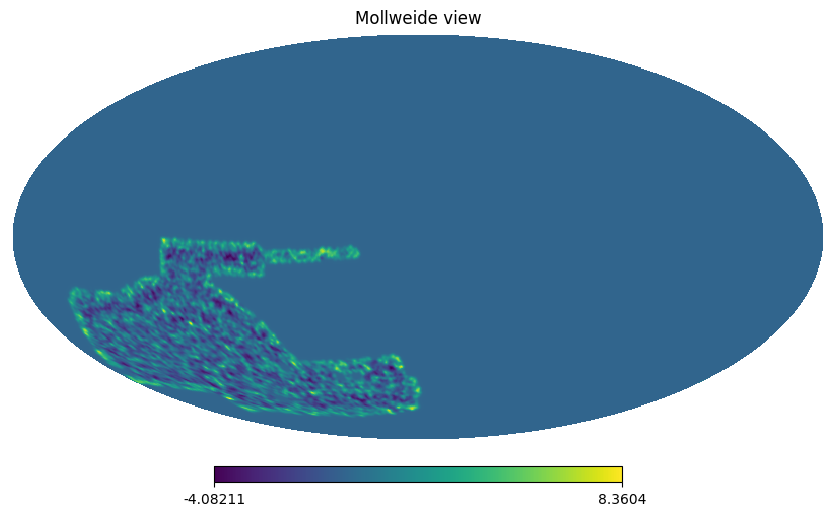

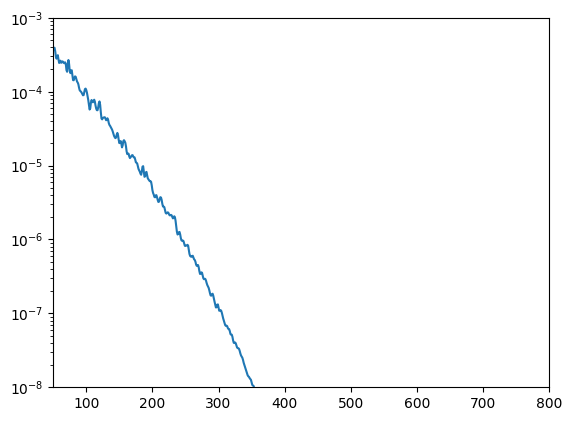

In [9]:
hp_maps = np.zeros((n_pix, n_channels))
hp_maps[dv_pix] = dv[i_batch]
hp_maps, _ = scales.map_to_smoothed_map(hp_maps, n_side, l_min=None, theta_fwhm=list(actual_fwhm), arcmin=True, nest=True)

hp_gnoms = []
for i in range(n_channels):
    hp_gnoms.append(hp.gnomview(hp_maps[...,i], rot=(90, -30, 0), return_projected_map=True, no_plot=True, nest=True))

hp_gnoms = np.array(hp_gnoms)
hp_gnoms = np.ma.masked_where(hp_gnoms==0, hp_gnoms)

hp.mollview(hp_maps[:,i_channel], nest=True)

fig, ax = plt.subplots()
ax.plot(hp.anafast(hp.reorder(hp_maps[:,i_channel], n2r=True)))
ax.set(yscale="log", xlim=(50,800), ylim=(1e-8, 1e-3))

### with hard cut along the padded footprint

In [10]:
# hp_maps = np.zeros((n_pix, n_channels))
# hp_maps[dv_pix] = dv[i_batch]
# hp_maps, _ = scales.map_to_smoothed_map(hp_maps, n_side, l_min=None, theta_fwhm=list(actual_fwhm), arcmin=True, nest=True)

# np_mask = np.zeros((n_pix, n_channels), dtype=bool)
# np_mask[dv_pix] = True

# hp_maps[~np_mask] = 0

# # hp_gnoms = []
# # for i in range(n_channels):
# #     hp_gnoms.append(hp.gnomview(hp_maps[...,i], rot=(90, -30, 0), return_projected_map=True, no_plot=True, nest=True))

# # hp_gnoms = np.array(hp_gnoms)
# # hp_gnoms = np.ma.masked_where(hp_gnoms==0, hp_gnoms)

# hp.mollview(hp_maps[:,i_channel], nest=True)

# fig, ax = plt.subplots()
# ax.plot(hp.anafast(hp.reorder(hp_maps[:,i_channel], n2r=True)))
# ax.set(yscale="log", xlim=(50,800), ylim=(1e-8, 1e-3))

### tensorflow

[None, (50.0, 800.0), (1e-08, 0.001)]

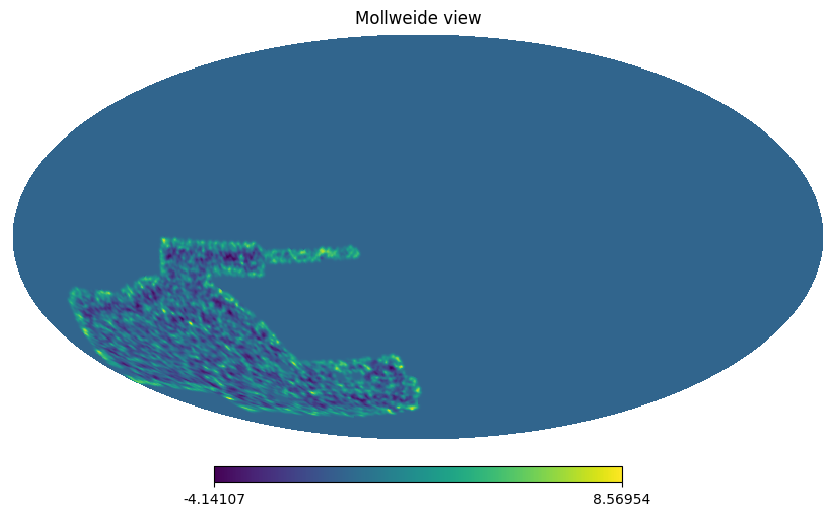

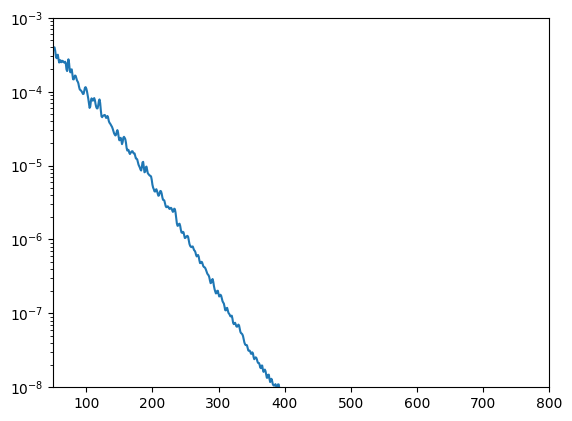

In [11]:
tf_maps = np.zeros((n_pix, n_channels))
tf_maps[dv_pix] = tf_smooth.numpy()[i_batch]

tf_gnoms = []
for i in range(n_channels):
    tf_gnoms.append(hp.gnomview(tf_maps[...,i], rot=(90, -30, 0), return_projected_map=True, no_plot=True, nest=True))
    
tf_gnoms = np.array(tf_gnoms)
tf_gnoms = np.ma.masked_where(tf_gnoms==0, tf_gnoms)

hp.mollview(tf_maps[:,i_channel], nest=True)

fig, ax = plt.subplots()
ax.plot(hp.anafast(hp.reorder(tf_maps[:,i_channel], n2r=True)))
ax.set(yscale="log", xlim=(50,800), ylim=(1e-8, 1e-3))

### comparison

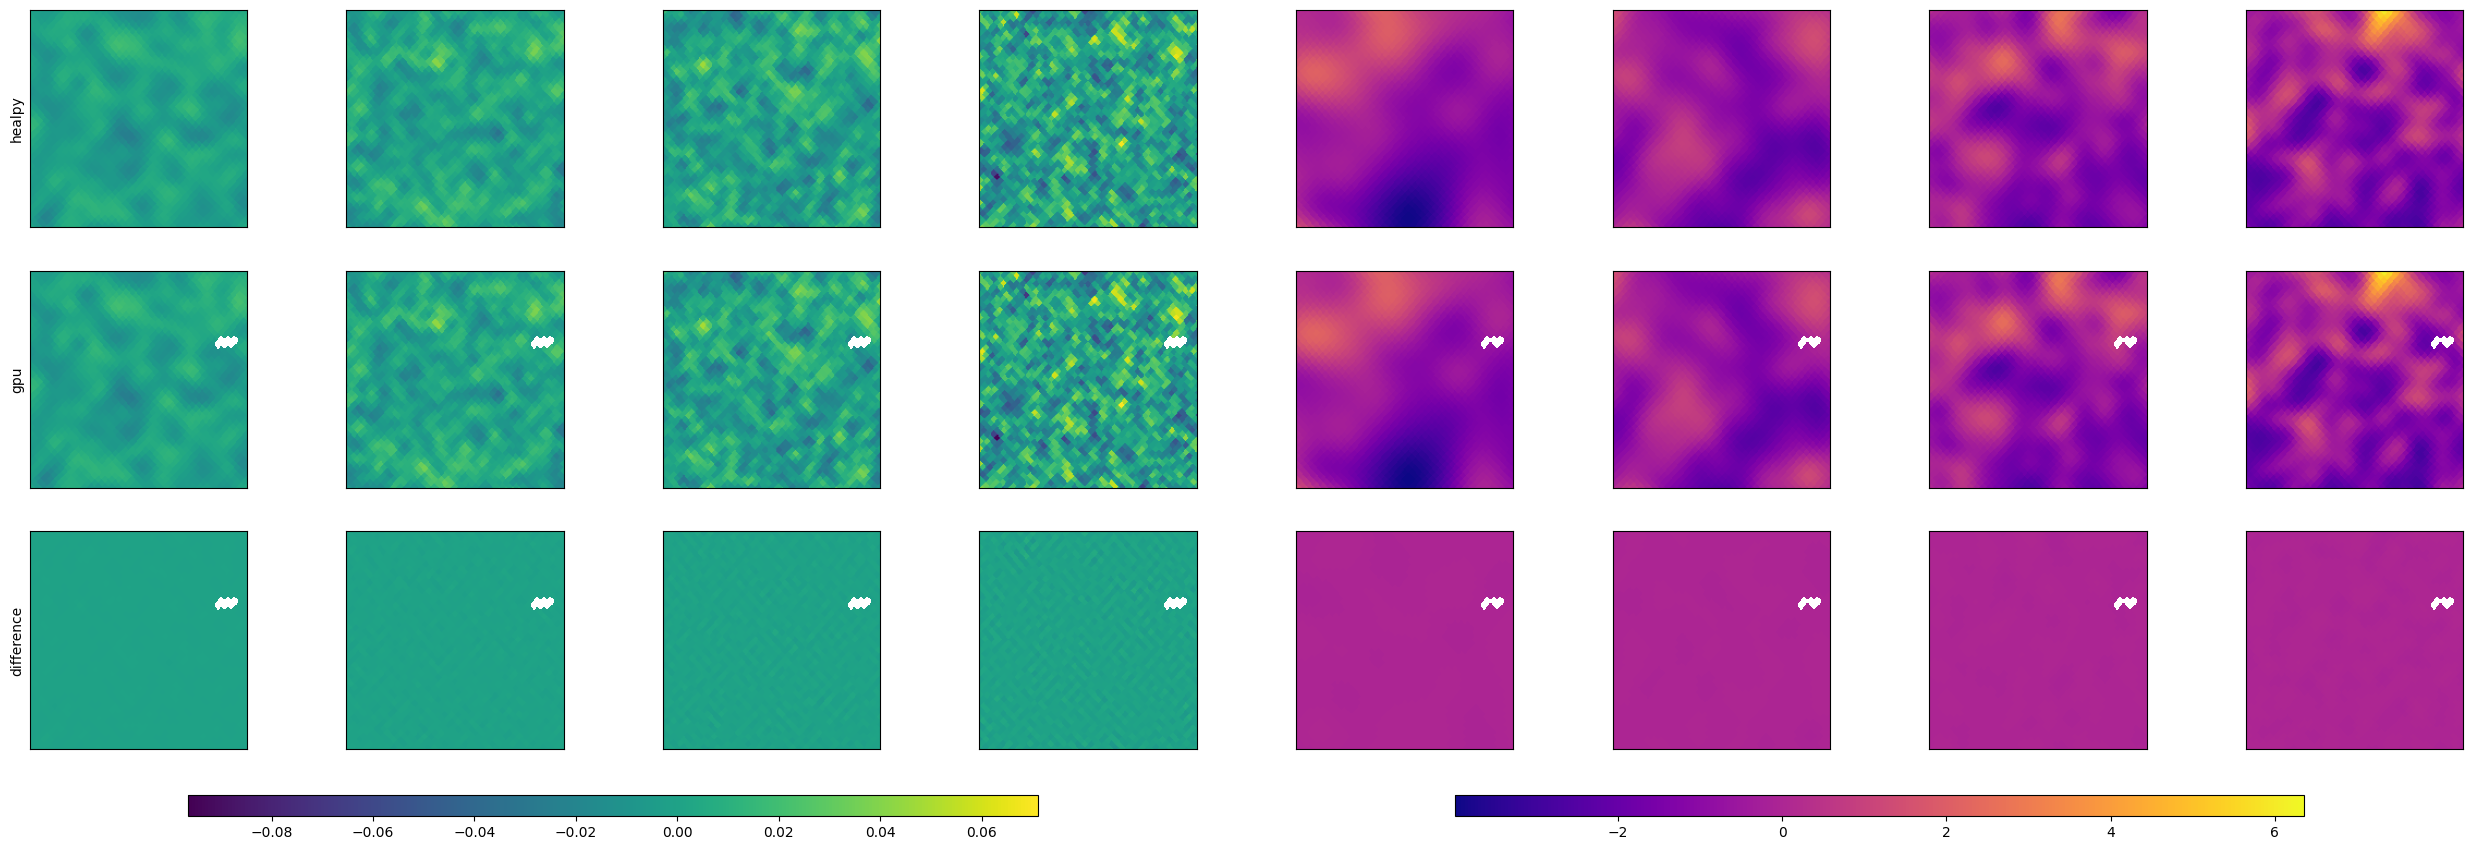

In [12]:
wl_min = tf_gnoms[:n_z_metacal].min()
wl_max = tf_gnoms[:n_z_metacal].max()

gc_min = tf_gnoms[n_z_metacal:].min()
gc_max = tf_gnoms[n_z_metacal:].max()

fig, ax = plt.subplots(figsize=(4*n_channels, 4*3), nrows=3, ncols=n_channels)

for i in range(n_channels):
    # lensing
    if i < n_z_metacal:
        vmin = wl_min
        vmax = wl_max
        cmap = "viridis"

    # clustering
    else:
        vmin = gc_min
        vmax = gc_max
        cmap = "plasma"

    im = ax[0,i].imshow(hp_gnoms[i], vmin=vmin, vmax=vmax, cmap=cmap)
    im = ax[1,i].imshow(tf_gnoms[i], vmin=vmin, vmax=vmax, cmap=cmap)
    
    diff = hp_gnoms[i] - tf_gnoms[i]
    im = ax[2,i].imshow(diff, vmin=vmin, vmax=vmax, cmap=cmap)
    
    # cosmetics
    for j in range(3):
        ax[j, i].set_xticks([])
        ax[j, i].set_yticks([])
        ax[j, i].set_aspect("equal")
        
    if i == 0:
        fig.colorbar(im, ax=ax[:,:n_z_metacal], orientation="horizontal", shrink=0.7, aspect=40, pad=0.05)
    if i == 4:
        fig.colorbar(im, ax=ax[:,n_z_metacal:], orientation="horizontal", shrink=0.7, aspect=40, pad=0.05)

        
ax[0,0].set(ylabel="healpy")
ax[1,0].set(ylabel="gpu")
ax[2,0].set(ylabel="difference")

fig.savefig(f"plots/smoothing-n_sigma{n_sigma_support}-fwhm{actual_fwhm}.png", bbox_inches="tight", dpi=100)

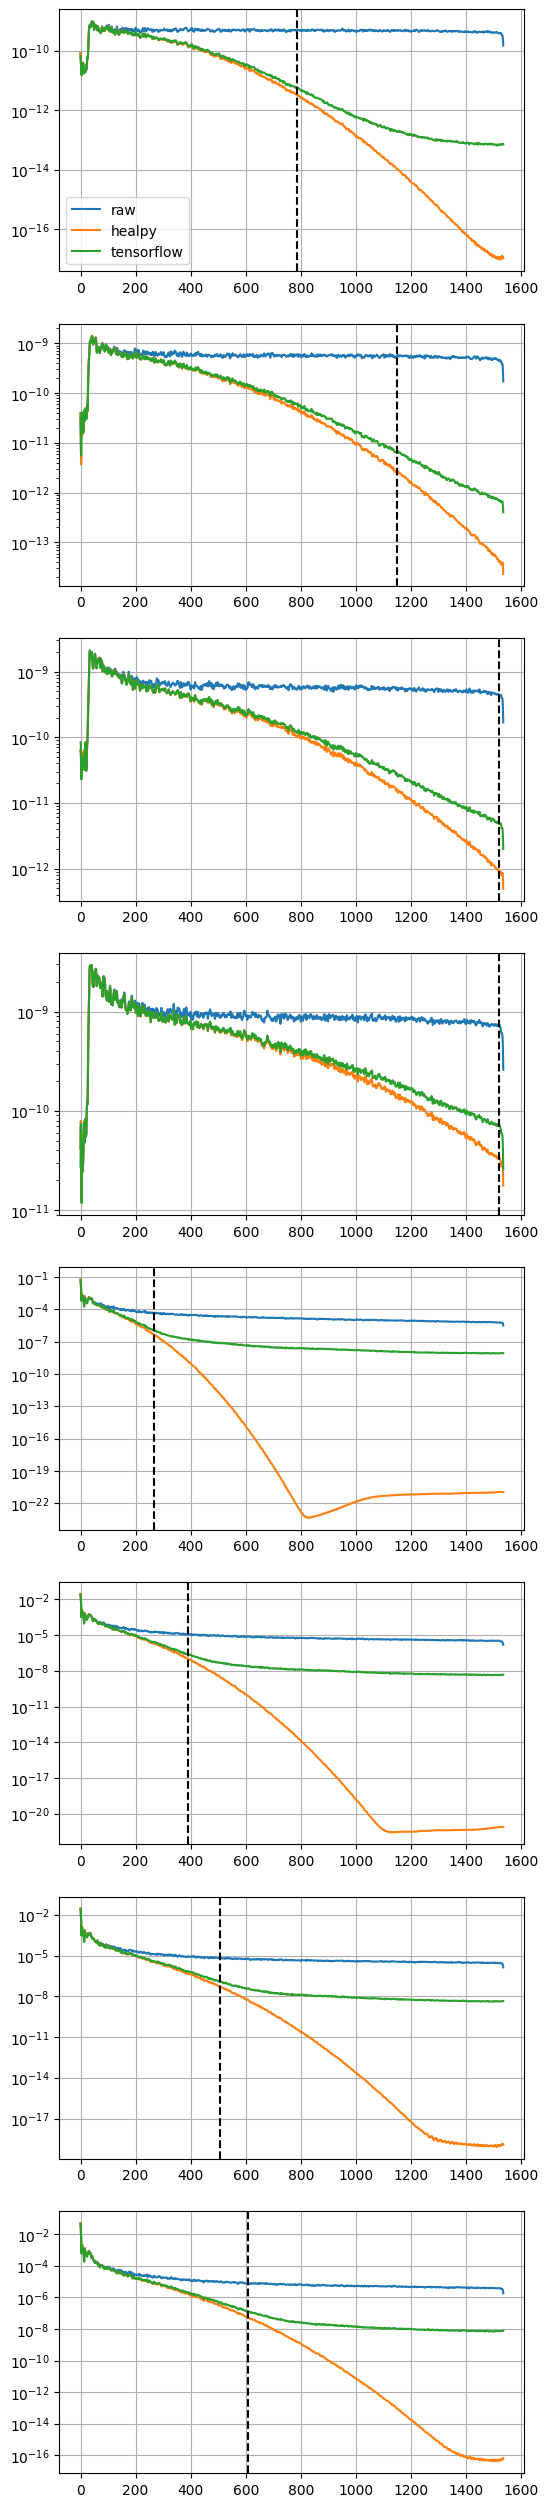

In [13]:
fig, ax = plt.subplots(nrows=n_channels, figsize=(6, 4*n_channels), sharex=False)

l_maxs = [785, 1150, 1519, 1519, 265, 389, 508, 608]

for i in range(n_channels):
    raw_cls = hp.anafast(hp.reorder(raw_maps[:,i], n2r=True))
    hp_cls = hp.anafast(hp.reorder(hp_maps[:,i], n2r=True))
    tf_cls = hp.anafast(hp.reorder(tf_maps[:,i], n2r=True))
        
    ax[i].plot(raw_cls, label="raw")
    ax[i].plot(hp_cls, label="healpy")
    ax[i].plot(tf_cls, label="tensorflow")
    ax[i].axvline(l_maxs[i], color="k", linestyle="--")
    
    l_min = 30
    l_max = int(l_maxs[i]*1.2)
    # ax[i].set(yscale="log", xlim=(l_min, l_max), ylim=(0.5*hp_cls[l_min:l_max].min(), 1.5*hp_cls[l_min:l_max].max()))
    ax[i].set(yscale="log")
    ax[i].grid()
    
ax[0].legend()

# repetitions

In [14]:
l_max_global = 3 * n_side - 1
fwhm = 65
data_vec_pix = grid_pipe.data_vec_pix

i_example = 0
i_bin = 0
# i_bin = 4

raw_map = np.zeros(n_pix)
raw_map[data_vec_pix] = dv[i_example,:,i_bin]
raw_map = hp.reorder(raw_map, n2r=True)
raw_cls = hp.anafast(raw_map, lmax=l_max_global-1)

l = np.arange(l_max_global)
low_pass_fac_cls = scales.gaussian_low_pass_factor_alm(l, theta_fwhm=fwhm)**2
smoothed_cls = raw_cls * low_pass_fac_cls

### single repetition

In [15]:
smoothing_layer_1 = healpy_layers.HealpySmoothing(
    nside=n_side, 
    indices=dv_pix,
    mask=mask,
    fwhm=fwhm,
    n_sigma_support=3,
    per_channel_repetitions=[1]*dv.shape[-1],
)

smoothing_layer_1 = tf.function(smoothing_layer_1)

Using the per channel smoothing repetitions [1 1 1 1 1 1 1 1]
Using the per channel smoothing scales sigma = [27.6 27.6 27.6 27.6 27.6 27.6 27.6 27.6] arcmin, fwhm = [65. 65. 65. 65. 65. 65. 65. 65.] arcmin
Creating tree for 464896 pixels and radius n_sigma_support * sigma = 82.81 arcmin
The maximal number of neighbors within that radius is 464


querying the tree: 100%|██████████| 100/100 [02:14<00:00,  1.34s/it]


Successfully created the sparse kernel tensor


In [16]:
# trace the function once
tf_smooth_1 = smoothing_layer_1(dv)

tf_map_1 = np.zeros(n_pix)
tf_map_1[data_vec_pix] = tf_smooth_1[i_example,:,i_bin]
tf_map_1 = hp.reorder(tf_map_1, n2r=True)
smoothed_cls_1 = hp.anafast(tf_map_1, lmax=l_max_global-1)

Successfully built the smoothing layer
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 13 splits. Beware of the resulting performance penalty.


In [17]:
# %%time
# tf_smooth = smoothing_layer_1(dv)

### multiple repetitions

In [18]:
repetitions = 49

smoothing_layer_2 = healpy_layers.HealpySmoothing(
    nside=n_side, 
    indices=dv_pix,
    mask=mask,
    fwhm=fwhm/np.sqrt(repetitions),
    n_sigma_support=7,
    per_channel_repetitions=[repetitions]*dv.shape[-1],
)
smoothing_layer_2 = tf.function(smoothing_layer_2)

Using the per channel smoothing repetitions [49 49 49 49 49 49 49 49]
Using the per channel smoothing scales sigma = [27.6 27.6 27.6 27.6 27.6 27.6 27.6 27.6] arcmin, fwhm = [65. 65. 65. 65. 65. 65. 65. 65.] arcmin
Creating tree for 464896 pixels and radius n_sigma_support * sigma = 27.60 arcmin
The maximal number of neighbors within that radius is 55


querying the tree: 100%|██████████| 100/100 [00:31<00:00,  3.14it/s]


Successfully created the sparse kernel tensor


In [19]:
# trace the function once
# tf_smooth_2 = smoothing_layer_2(dv)

dv_64 = tf.cast(dv, tf.float64)
tf_smooth_2 = smoothing_layer_2(dv_64)

tf_map_2 = np.zeros(n_pix)
tf_map_2[data_vec_pix] = tf_smooth_2[i_example,:,i_bin]
tf_map_2 = hp.reorder(tf_map_2, n2r=True)
smoothed_cls_2 = hp.anafast(tf_map_2, lmax=l_max_global-1)

Successfully built the smoothing layer


In [20]:
# %%time
# tf_smooth_2 = smoothing_layer_2(dv)

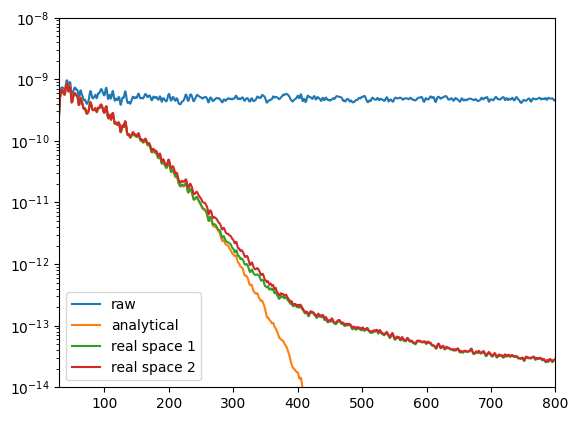

In [21]:
fig, ax = plt.subplots()

ax.plot(raw_cls, label="raw")
ax.plot(smoothed_cls, label="analytical")
ax.plot(smoothed_cls_1, label="real space 1")
ax.plot(smoothed_cls_2, label="real space 2")

# ax.set(yscale="log", xlim=(30, 800), ylim=(1e-12,1e-3))
ax.set(yscale="log", xlim=(30, 800), ylim=(1e-14,1e-8))
ax.legend()

# sigma

In [22]:
smoothing_layer_1 = healpy_layers.HealpySmoothing(
    nside=n_side, 
    indices=dv_pix,
    mask=mask,
    fwhm=fwhm/np.sqrt(repetitions),
    n_sigma_support=3,
    per_channel_repetitions=[repetitions]*dv.shape[-1],
)
smoothing_layer_1 = tf.function(smoothing_layer_1)

smoothing_layer_2 = healpy_layers.HealpySmoothing(
    nside=n_side, 
    indices=dv_pix,
    mask=mask,
    fwhm=fwhm/np.sqrt(repetitions),
    n_sigma_support=7,
    per_channel_repetitions=[repetitions]*dv.shape[-1],
)
smoothing_layer_2 = tf.function(smoothing_layer_2)

Using the per channel smoothing repetitions [49 49 49 49 49 49 49 49]
Using the per channel smoothing scales sigma = [27.6 27.6 27.6 27.6 27.6 27.6 27.6 27.6] arcmin, fwhm = [65. 65. 65. 65. 65. 65. 65. 65.] arcmin
Creating tree for 464896 pixels and radius n_sigma_support * sigma = 11.83 arcmin
The maximal number of neighbors within that radius is 11


querying the tree: 100%|██████████| 100/100 [00:18<00:00,  5.33it/s]


Successfully created the sparse kernel tensor
Using the per channel smoothing repetitions [49 49 49 49 49 49 49 49]
Using the per channel smoothing scales sigma = [27.6 27.6 27.6 27.6 27.6 27.6 27.6 27.6] arcmin, fwhm = [65. 65. 65. 65. 65. 65. 65. 65.] arcmin
Creating tree for 464896 pixels and radius n_sigma_support * sigma = 27.60 arcmin
The maximal number of neighbors within that radius is 55


querying the tree: 100%|██████████| 100/100 [00:31<00:00,  3.13it/s]


Successfully created the sparse kernel tensor


In [23]:
# trace the function once
tf_smooth_1 = smoothing_layer_1(dv)

tf_map_1 = np.zeros(n_pix)
tf_map_1[data_vec_pix] = tf_smooth_1[i_example,:,i_bin]
tf_map_1 = hp.reorder(tf_map_1, n2r=True)
smoothed_cls_1 = hp.anafast(tf_map_1, lmax=l_max_global-1)

# trace the function once
tf_smooth_2 = smoothing_layer_2(dv)

tf_map_2 = np.zeros(n_pix)
tf_map_2[data_vec_pix] = tf_smooth_2[i_example,:,i_bin]
tf_map_2 = hp.reorder(tf_map_2, n2r=True)
smoothed_cls_2 = hp.anafast(tf_map_2, lmax=l_max_global-1)

Successfully built the smoothing layer
Successfully built the smoothing layer


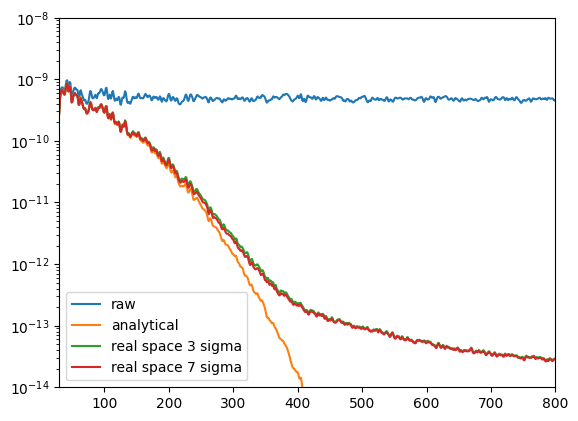

In [24]:
fig, ax = plt.subplots()

ax.plot(raw_cls, label="raw")
ax.plot(smoothed_cls, label="analytical")
ax.plot(smoothed_cls_1, label="real space 3 sigma")
ax.plot(smoothed_cls_2, label="real space 7 sigma")

# ax.set(yscale="log", xlim=(30, 800), ylim=(1e-12,1e-3))
ax.set(yscale="log", xlim=(30, 800), ylim=(1e-14,1e-8))
ax.legend()